# Cross-Lingual Phoneme Graph Embeddings

Embeds every phoneme from every language in `ipa-mappings` into a **shared geometric space**, using:

- **Node features** — articulatory feature vectors from `distance.vectorize_phones` (21-dim SPE/IPA)
- **Intra-language edges** — allophone pairs within the same language
- **Inter-language edges** — same IPA symbol shared across languages; ancestry-weighted language similarity
- **Graph Laplacian** and **node2vec** embeddings on the resulting heterogeneous graph

### Why this is interesting for this project
Languages sharing phonemes via ancestry appear **nearby** in the embedding space. Substrate / superstrate relationships create **gradient bridges**. You can cluster phonemes across languages, measure inventory coverage gaps, and find which phonemes are cross-linguistically "central".

In [1]:
# ── Dependencies ──────────────────────────────────────────────────────────────
# Run this cell first. Restart kernel if prompted.

%pip install numpy==1.26.4           # array ops
%pip install scipy==1.13.0           # sparse matrices, Laplacian eigenvectors
%pip install networkx==3.3           # graph construction and analysis
%pip install scikit-learn==1.4.2     # UMAP fallback (PCA, KMeans)
%pip install umap-learn==0.5.6       # UMAP dimensionality reduction for visualization
%pip install matplotlib==3.8.4       # plotting
%pip install seaborn==0.13.2         # statistical plots
%pip install pandas==2.2.2           # tabular results
%pip install psutil==5.9.8           # memory monitoring
%pip install mlflow==2.12.2          # experiment tracking (optional)
# node2vec — pure python, no torch required
%pip install node2vec==0.4.6         # random-walk based graph embeddings
# ipa-mappings — install from local path or PyPI
# %pip install ipa-mappings           # uncomment if installed from PyPI
# %pip install -e /path/to/ipa-mappings  # uncomment for local editable install


[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.
  Using cached networkx-3.3-py3-none-any.whl.metadata (5.1 kB)
Using cached networkx-3.3-py3-none-any.whl (1.7 MB)
  Attempting uninstall: networkx
    Found existing installation: networkx 2.8.8
    Uninstalling networkx-2.8.8:
      Successfully uninstalled networkx-2.8.8
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
nemo-run 0.4.0 requires cryptography<43.0.0, but you have cryptography 46.0.5 which is incompatible.
node2vec 0.4.6 requires networkx<3.0,>=2.5, but you have networkx 3.3 which is incompatible

In [2]:
import os, gc
import psutil

# ── Configuration ─────────────────────────────────────────────────────────────

# Which languages to include. "" = all available codes.
LANG_CODES            = os.getenv("LANG_CODES", "")              # comma-separated, "" = all
LANG_FAMILY_FILTER    = os.getenv("LANG_FAMILY_FILTER", "")      # e.g. "Romance" to restrict

# Edge weight controls
W_SAME_IPA            = float(os.getenv("W_SAME_IPA", "1.0"))    # weight for same-IPA cross-lang edges
W_ALLOPHONE           = float(os.getenv("W_ALLOPHONE", "0.7"))   # weight for allophone intra-lang edges
W_ANCESTRY            = float(os.getenv("W_ANCESTRY", "0.5"))    # weight scaling for ancestry edges
W_FEAT_SIMILARITY     = float(os.getenv("W_FEAT_SIMILARITY", "0.3")) # feature-sim edges between near phonemes
FEAT_SIM_THRESHOLD    = float(os.getenv("FEAT_SIM_THRESHOLD", "0.85")) # min cosine sim to add feat-sim edge

# Embedding method: "laplacian" | "node2vec"
EMBED_METHOD          = os.getenv("EMBED_METHOD", "node2vec")
EMBED_DIM             = int(os.getenv("EMBED_DIM", "64"))         # embedding dimensionality

# node2vec hyperparameters
N2V_WALK_LENGTH       = int(os.getenv("N2V_WALK_LENGTH", "30"))
N2V_NUM_WALKS         = int(os.getenv("N2V_NUM_WALKS", "200"))
N2V_P                 = float(os.getenv("N2V_P", "1.0"))         # return parameter
N2V_Q                 = float(os.getenv("N2V_Q", "0.5"))         # in-out parameter (< 1 = DFS/community)
N2V_WORKERS           = int(os.getenv("N2V_WORKERS", "4"))

# Output
OUTPUT_DIR            = os.getenv("OUTPUT_DIR", "./outputs")
ONNX_EXPORT_PATH      = os.getenv("ONNX_EXPORT_PATH", f"{OUTPUT_DIR}/phoneme_embeddings.onnx")
ONNX_OPSET            = int(os.getenv("ONNX_OPSET", "17"))
QUANTIZE_MODE         = os.getenv("QUANTIZE_MODE", "dynamic")    # static/dynamic/none
QUANTIZE_OUTPUT_PATH  = os.getenv("QUANTIZE_OUTPUT_PATH", f"{OUTPUT_DIR}/phoneme_embeddings_int8.onnx")

# MLflow
MLFLOW_TRACKING_URI   = os.getenv("MLFLOW_TRACKING_URI", "http://localhost:5000")
MLFLOW_EXPERIMENT     = os.getenv("MLFLOW_EXPERIMENT", "phoneme-graph-embeddings")
MLFLOW_RUN_NAME       = os.getenv("MLFLOW_RUN_NAME", None)

# HuggingFace
HF_TOKEN              = os.getenv("HF_TOKEN", None)
HF_MODEL_REPO         = os.getenv("HF_MODEL_REPO", None)
HF_UPLOAD_MODEL       = os.getenv("HF_UPLOAD_MODEL", "false").lower() == "true"

os.makedirs(OUTPUT_DIR, exist_ok=True)

def memory_checkpoint(label):
    gc.collect()
    m = psutil.virtual_memory()
    print(f"🧠 [{label}] RAM: {m.used/1e9:.2f} GB / {m.total/1e9:.2f} GB ({m.percent:.1f}%)")

print("✅ Configuration loaded")
print(f"   Embed method: {EMBED_METHOD} | Dim: {EMBED_DIM} | Family filter: '{LANG_FAMILY_FILTER or 'all'}'")

✅ Configuration loaded
   Embed method: node2vec | Dim: 64 | Family filter: 'all'


In [3]:
# ── MLflow setup (optional) ───────────────────────────────────────────────────
try:
    import mlflow
    mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)
    mlflow.set_experiment(MLFLOW_EXPERIMENT)
    MLFLOW_AVAILABLE = True
    print("✅ MLflow connected")
except Exception as e:
    MLFLOW_AVAILABLE = False
    print(f"⚠️  MLflow unavailable: {e}")

def log_metric(key, value, step=None):
    if MLFLOW_AVAILABLE:
        mlflow.log_metric(key, value, step=step)

def log_artifact(path):
    if MLFLOW_AVAILABLE and os.path.exists(path):
        mlflow.log_artifact(path)

⚠️  MLflow unavailable: API request to http://localhost:5000/api/2.0/mlflow/experiments/get-by-name failed with exception HTTPConnectionPool(host='localhost', port=5000): Max retries exceeded with url: /api/2.0/mlflow/experiments/get-by-name?experiment_name=phoneme-graph-embeddings (Caused by NewConnectionError("HTTPConnection(host='localhost', port=5000): Failed to establish a new connection: [Errno 111] Connection refused"))


## 📊 1. Load Language Inventories

In [4]:
import sys
sys.path.insert(0, "..")  # adjust if running from a different directory

import orthography2ipa
from orthography2ipa.distance import feature_vector, segment_distance, ancestry_similarity

# ── Collect all language specs ─────────────────────────────────────────────────
if LANG_CODES:
    codes = [c.strip() for c in LANG_CODES.split(",")]
else:
    codes = orthography2ipa.available_codes()

specs = {}
skipped = []
for code in codes:
    try:
        spec = orthography2ipa.get(code)
        if LANG_FAMILY_FILTER and spec.family != LANG_FAMILY_FILTER:
            continue
        specs[code] = spec
    except Exception as e:
        skipped.append((code, str(e)))

print(f"✅ Loaded {len(specs)} language specs")
if skipped:
    print(f"⚠️  Skipped {len(skipped)}: {[c for c,_ in skipped[:5]]}...")

# ── Extract phoneme inventories ───────────────────────────────────────────────
lang_phonemes = {}  # code -> set of IPA strings
for code, spec in specs.items():
    phones = set()
    for ipa_list in spec.graphemes.values():
        for ipa in ipa_list:
            if ipa and ipa not in ("", "∅"):
                phones.add(ipa)
    lang_phonemes[code] = phones

all_ipa = sorted(set().union(*lang_phonemes.values()))
print(f"   Total unique IPA segments across all languages: {len(all_ipa)}")
memory_checkpoint("after inventory load")

✅ Loaded 223 language specs
   Total unique IPA segments across all languages: 529
🧠 [after inventory load] RAM: 11.92 GB / 33.36 GB (37.8%)


## 🔍 2. EDA — Inventory Statistics

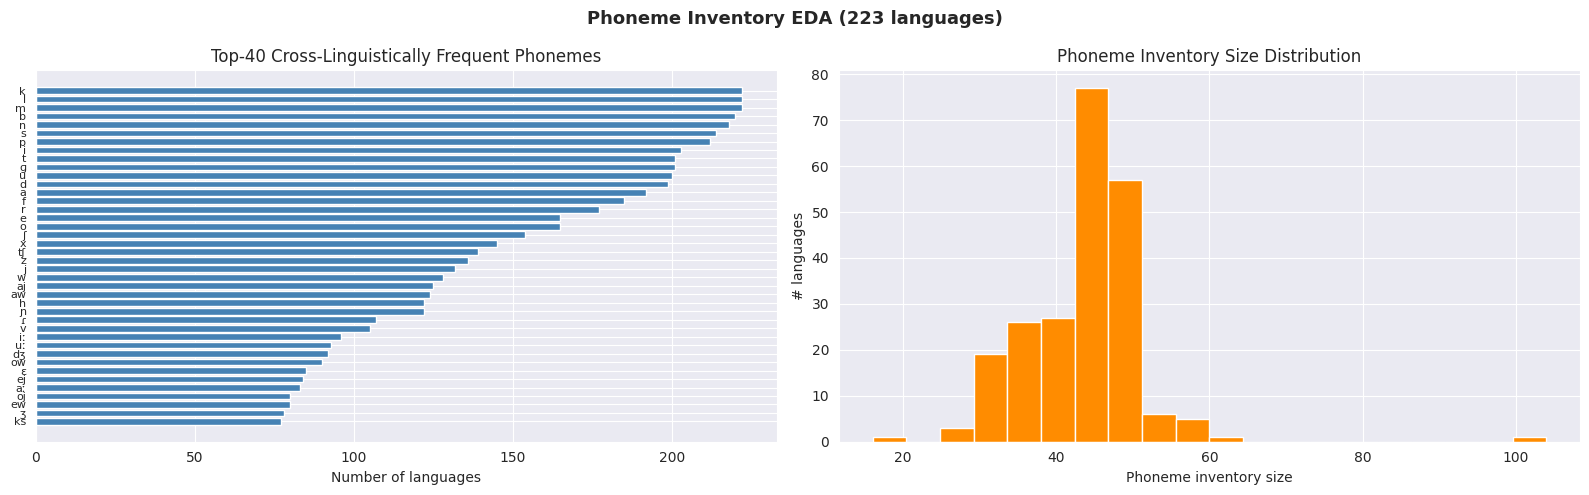

Most universal phoneme: 'k' (222 langs)
Most unique (singleton) phonemes: 251


In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

# How many languages does each IPA segment appear in?
ipa_freq = Counter()
for phones in lang_phonemes.values():
    for p in phones:
        ipa_freq[p] += 1

freq_df = pd.DataFrame(ipa_freq.most_common(40), columns=["phoneme", "n_languages"])

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Plot 1: top-40 most cross-linguistically common phonemes
axes[0].barh(freq_df["phoneme"][::-1], freq_df["n_languages"][::-1], color="steelblue")
axes[0].set_xlabel("Number of languages")
axes[0].set_title("Top-40 Cross-Linguistically Frequent Phonemes")
axes[0].tick_params(axis='y', labelsize=8)

# Plot 2: inventory size distribution
sizes = [len(p) for p in lang_phonemes.values()]
axes[1].hist(sizes, bins=20, color="darkorange", edgecolor="white")
axes[1].set_xlabel("Phoneme inventory size")
axes[1].set_ylabel("# languages")
axes[1].set_title("Phoneme Inventory Size Distribution")

plt.suptitle(f"Phoneme Inventory EDA ({len(specs)} languages)", fontsize=13, fontweight="bold")
plt.tight_layout()
eda_path = f"{OUTPUT_DIR}/eda_inventories.png"
plt.savefig(eda_path, dpi=120, bbox_inches="tight")
log_artifact(eda_path)
plt.show()

print(f"Most universal phoneme: '{freq_df.iloc[0].phoneme}' ({freq_df.iloc[0].n_languages} langs)")
print(f"Most unique (singleton) phonemes: {sum(1 for v in ipa_freq.values() if v == 1)}")

## 🕸️ 3. Build the Phoneme Graph

In [6]:
import networkx as nx

# Node ID convention: "<lang_code>:<IPA>"  e.g. "es:b", "pt:v"
# This allows the same IPA symbol to be distinct nodes per language
# while cross-language edges connect them.

G = nx.Graph()

# ── 1. Add nodes (one per lang×phoneme) ──────────────────────────────────────
node_meta = {}  # node_id -> {lang, ipa, family, feat_vec}
for code, phones in lang_phonemes.items():
    spec = specs[code]
    for ipa in phones:
        nid = f"{code}:{ipa}"
        try:
            fv = feature_vector(ipa)  # list of True/False/None
            fv_num = np.array([0.5 if v is None else float(v) for v in fv], dtype=np.float32)
        except Exception:
            fv_num = np.zeros(21, dtype=np.float32)
        G.add_node(nid)
        node_meta[nid] = {
            "lang": code, "ipa": ipa,
            "family": spec.family, "feat_vec": fv_num
        }

print(f"✅ Nodes: {G.number_of_nodes()}")

# ── 2. Intra-language allophone edges ─────────────────────────────────────────
allophone_edges = 0
for code, spec in specs.items():
    for phoneme, allophones in spec.allophones.items():
        src = f"{code}:{phoneme}"
        if src not in G:
            continue
        for allo in allophones:
            tgt = f"{code}:{allo}"
            if tgt in G and tgt != src:
                G.add_edge(src, tgt, weight=W_ALLOPHONE, etype="allophone")
                allophone_edges += 1

print(f"   Allophone edges: {allophone_edges}")

# ── 3. Cross-language same-IPA edges ──────────────────────────────────────────
# Group all nodes by their raw IPA symbol
from collections import defaultdict
ipa_to_nodes = defaultdict(list)
for nid, meta in node_meta.items():
    ipa_to_nodes[meta["ipa"]].append(nid)

same_ipa_edges = 0
for ipa, nodes in ipa_to_nodes.items():
    for i in range(len(nodes)):
        for j in range(i + 1, len(nodes)):
            G.add_edge(nodes[i], nodes[j], weight=W_SAME_IPA, etype="same_ipa")
            same_ipa_edges += 1

print(f"   Same-IPA cross-lang edges: {same_ipa_edges}")

# ── 4. Ancestry-weighted cross-language edges ─────────────────────────────────
# For each pair of languages with a shared ancestor, upweight edges between
# their shared IPA segments proportionally to ancestry similarity.
ancestry_edges = 0
lang_codes_list = list(specs.keys())
for i, code_a in enumerate(lang_codes_list):
    for code_b in lang_codes_list[i + 1:]:
        try:
            anc_sim = ancestry_similarity(specs[code_a], specs[code_b])
        except Exception:
            anc_sim = 0.0
        if anc_sim < 0.05:
            continue
        # Strengthen existing same-IPA edges between these two languages
        shared = lang_phonemes[code_a] & lang_phonemes[code_b]
        for ipa in shared:
            src = f"{code_a}:{ipa}"
            tgt = f"{code_b}:{ipa}"
            if G.has_edge(src, tgt):
                G[src][tgt]["weight"] += W_ANCESTRY * anc_sim
            else:
                G.add_edge(src, tgt, weight=W_ANCESTRY * anc_sim, etype="ancestry")
            ancestry_edges += 1

print(f"   Ancestry-weighted edges added/strengthened: {ancestry_edges}")

# ── 5. Feature-similarity edges (near-phoneme pairs) ─────────────────────────
# Connect phonemes across languages that are articulatorily very similar
# but not identical IPA (e.g. /p/ and /pʰ/, /β/ and /v/).
feat_sim_edges = 0
all_nodes = list(G.nodes())
# Only compute within same language family to keep this tractable
family_nodes = defaultdict(list)
for nid in all_nodes:
    family_nodes[node_meta[nid]["family"]].append(nid)

for family, fnodes in family_nodes.items():
    vecs = np.stack([node_meta[n]["feat_vec"] for n in fnodes])
    # Cosine similarity
    norms = np.linalg.norm(vecs, axis=1, keepdims=True) + 1e-8
    vecs_norm = vecs / norms
    sim_matrix = vecs_norm @ vecs_norm.T
    rows, cols = np.where((sim_matrix > FEAT_SIM_THRESHOLD) & (sim_matrix < 0.9999))
    for r, c in zip(rows, cols):
        if r >= c:
            continue
        src, tgt = fnodes[r], fnodes[c]
        if node_meta[src]["lang"] == node_meta[tgt]["lang"]:
            continue  # skip intra-lang (allophone edges cover that)
        if not G.has_edge(src, tgt):
            G.add_edge(src, tgt, weight=W_FEAT_SIMILARITY * float(sim_matrix[r, c]), etype="feat_sim")
            feat_sim_edges += 1

print(f"   Feature-similarity edges: {feat_sim_edges}")
print(f"\n📊 Graph summary: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")
memory_checkpoint("after graph build")

✅ Nodes: 9698
   Allophone edges: 718
   Same-IPA cross-lang edges: 538132
   Ancestry-weighted edges added/strengthened: 354203
   Feature-similarity edges: 765242

📊 Graph summary: 9698 nodes, 1304081 edges
🧠 [after graph build] RAM: 12.48 GB / 33.36 GB (39.5%)


## 🏋️ 4. Compute Embeddings

In [ ]:
import numpy as np

node_list = list(G.nodes())  # stable ordering
node_idx  = {n: i for i, n in enumerate(node_list)}
N = len(node_list)

if EMBED_METHOD == "laplacian":
    # ── Graph Laplacian Eigenmaps ─────────────────────────────────────────────
    from scipy.sparse import csr_matrix
    from scipy.sparse.linalg import eigsh

    print("Building weighted adjacency matrix...")
    rows, cols, data = [], [], []
    for u, v, w in G.edges(data="weight", default=1.0):
        i, j = node_idx[u], node_idx[v]
        rows += [i, j]; cols += [j, i]; data += [w, w]

    A = csr_matrix((data, (rows, cols)), shape=(N, N), dtype=np.float32)
    D = np.array(A.sum(axis=1)).flatten()
    D_inv_sqrt = 1.0 / (np.sqrt(D) + 1e-8)

    from scipy.sparse import diags
    D_mat = diags(D_inv_sqrt)
    L_sym = D_mat @ A @ D_mat  # normalized Laplacian

    k = min(EMBED_DIM + 1, N - 1)
    print(f"Computing top-{k} eigenvectors of normalized Laplacian (N={N})...")
    eigenvalues, eigenvectors = eigsh(L_sym, k=k, which="LM")
    # Skip the trivial eigenvector (largest eigenvalue ~ 1)
    idx_sort = np.argsort(eigenvalues)[::-1]
    embeddings = eigenvectors[:, idx_sort[1:EMBED_DIM + 1]]  # shape (N, EMBED_DIM)
    print(f"✅ Laplacian embeddings: {embeddings.shape}")

elif EMBED_METHOD == "node2vec":
    # ── node2vec Random Walk Embeddings ───────────────────────────────────────
    from node2vec import Node2Vec

    print(f"Running node2vec (walks={N2V_NUM_WALKS}, len={N2V_WALK_LENGTH}, p={N2V_P}, q={N2V_Q})...")
    n2v = Node2Vec(
        G,
        dimensions=EMBED_DIM,
        walk_length=N2V_WALK_LENGTH,
        num_walks=N2V_NUM_WALKS,
        p=N2V_P,
        q=N2V_Q,
        workers=N2V_WORKERS,
        weight_key="weight",
        quiet=False,
    )
    model = n2v.fit(window=10, min_count=1, batch_words=4)

    embeddings = np.stack([model.wv[n] for n in node_list]).astype(np.float32)
    print(f"✅ node2vec embeddings: {embeddings.shape}")
    # Save word2vec model
    model.wv.save_word2vec_format(f"{OUTPUT_DIR}/phoneme_node2vec.bin", binary=True)
else:
    raise ValueError(f"Unknown EMBED_METHOD: {EMBED_METHOD}")

# Attach embeddings to metadata
for i, nid in enumerate(node_list):
    node_meta[nid]["embedding"] = embeddings[i]

# Save raw embeddings
embed_path = f"{OUTPUT_DIR}/phoneme_embeddings.npy"
np.save(embed_path, embeddings)
node_list_path = f"{OUTPUT_DIR}/phoneme_node_list.txt"
with open(node_list_path, "w") as f:
    f.write("\n".join(node_list))
log_artifact(embed_path)
log_artifact(node_list_path)

log_metric("n_nodes", N)
log_metric("n_edges", G.number_of_edges())
log_metric("embed_dim", EMBED_DIM)
memory_checkpoint("after embedding")

Running node2vec (walks=200, len=30, p=1.0, q=0.5)...


Computing transition probabilities:   0%|          | 0/9698 [00:00<?, ?it/s]

## 📈 5. Visualize Embeddings

In [ ]:
# ── UMAP 2D projection ────────────────────────────────────────────────────────
try:
    import umap
    reducer = umap.UMAP(n_components=2, random_state=42, n_neighbors=15, min_dist=0.1)
    print("Fitting UMAP...")
    coords_2d = reducer.fit_transform(embeddings)
    print("✅ UMAP done")
except ImportError:
    from sklearn.decomposition import PCA
    print("⚠️ UMAP not available — using PCA fallback")
    coords_2d = PCA(n_components=2).fit_transform(embeddings)

# ── Plot coloured by language family ─────────────────────────────────────────
families = [node_meta[n]["family"] for n in node_list]
unique_families = sorted(set(families))
palette = plt.cm.tab20(np.linspace(0, 1, len(unique_families)))
family_color = {f: palette[i] for i, f in enumerate(unique_families)}
colors = [family_color[f] for f in families]

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Plot by family
ax = axes[0]
for fam in unique_families:
    mask = [i for i, f in enumerate(families) if f == fam]
    ax.scatter(coords_2d[mask, 0], coords_2d[mask, 1],
               c=[palette[unique_families.index(fam)]], label=fam, s=10, alpha=0.6)
ax.set_title(f"Phoneme Embeddings by Language Family\n({EMBED_METHOD}, {EMBED_DIM}d → 2d UMAP)")
ax.legend(fontsize=6, markerscale=2, loc="upper right", ncol=2)
ax.set_xlabel("UMAP-1"); ax.set_ylabel("UMAP-2")

# Annotate most frequent phonemes
common_ipa = [ipa for ipa, cnt in ipa_freq.most_common(20)]
for i, nid in enumerate(node_list):
    meta = node_meta[nid]
    if meta["ipa"] in common_ipa and meta["lang"] == list(specs.keys())[0]:
        ax.annotate(meta["ipa"], (coords_2d[i, 0], coords_2d[i, 1]),
                    fontsize=7, alpha=0.85, color="black")

# Plot by language (subsample if too many)
ax2 = axes[1]
langs = [node_meta[n]["lang"] for n in node_list]
unique_langs = sorted(set(langs))
palette2 = plt.cm.tab20(np.linspace(0, 1, min(len(unique_langs), 20)))
for k, lang in enumerate(unique_langs[:20]):
    mask = [i for i, l in enumerate(langs) if l == lang]
    ax2.scatter(coords_2d[mask, 0], coords_2d[mask, 1],
                c=[palette2[k]], label=lang, s=8, alpha=0.5)
ax2.set_title("Phoneme Embeddings by Language (top-20)")
ax2.legend(fontsize=5, markerscale=2, loc="upper right", ncol=3)
ax2.set_xlabel("UMAP-1"); ax2.set_ylabel("UMAP-2")

plt.tight_layout()
embed_plot_path = f"{OUTPUT_DIR}/embedding_umap.png"
plt.savefig(embed_plot_path, dpi=140, bbox_inches="tight")
log_artifact(embed_plot_path)
plt.show()
print(f"✅ UMAP plot saved: {embed_plot_path}")

In [ ]:
# ── Nearest-neighbor analysis ─────────────────────────────────────────────────
# For a query phoneme, find its k nearest neighbors across all languages

from sklearn.metrics.pairwise import cosine_similarity

def nearest_neighbors(query_node: str, k: int = 10, same_lang: bool = False):
    """Find k nearest phoneme embeddings to query_node."""
    if query_node not in node_idx:
        raise KeyError(f"Node '{query_node}' not in graph")
    q_vec = embeddings[node_idx[query_node]].reshape(1, -1)
    sims = cosine_similarity(q_vec, embeddings)[0]
    order = np.argsort(sims)[::-1]
    results = []
    for idx in order:
        nid = node_list[idx]
        if nid == query_node:
            continue
        if not same_lang and node_meta[nid]["lang"] == node_meta[query_node]["lang"]:
            continue
        results.append({"node": nid, "lang": node_meta[nid]["lang"],
                        "ipa": node_meta[nid]["ipa"],
                        "family": node_meta[nid]["family"],
                        "sim": float(sims[idx])})
        if len(results) >= k:
            break
    return results

# Example: find cross-lingual neighbors of Spanish /b/
query = "es:b"
if query in node_idx:
    print(f"\nNearest cross-lingual neighbors of [{query}]:")
    for nn in nearest_neighbors(query, k=10):
        print(f"  {nn['node']:25s}  family={nn['family']:15s}  sim={nn['sim']:.4f}")

# Example: find neighbors of English /θ/ (th)
query2 = "en:θ"
if query2 in node_idx:
    print(f"\nNearest cross-lingual neighbors of [{query2}]:")
    for nn in nearest_neighbors(query2, k=10):
        print(f"  {nn['node']:25s}  family={nn['family']:15s}  sim={nn['sim']:.4f}")

In [ ]:
# ── Language-level embeddings (centroid of phoneme embeddings) ───────────────
# Aggregate: each language's embedding = mean of its phoneme embeddings

lang_embeds = {}
for code in specs:
    idxs = [node_idx[f"{code}:{p}"] for p in lang_phonemes[code] if f"{code}:{p}" in node_idx]
    if idxs:
        lang_embeds[code] = embeddings[idxs].mean(axis=0)

lang_embed_matrix = np.stack(list(lang_embeds.values()))
lang_embed_labels = list(lang_embeds.keys())

# UMAP on language-level embeddings
try:
    import umap
    lang_coords = umap.UMAP(n_components=2, random_state=42, n_neighbors=min(10, len(lang_embed_labels)-1)).fit_transform(lang_embed_matrix)
except Exception:
    from sklearn.decomposition import PCA
    lang_coords = PCA(n_components=2).fit_transform(lang_embed_matrix)

fig, ax = plt.subplots(figsize=(14, 9))
family_of = {code: specs[code].family for code in lang_embed_labels}
fams = [family_of[c] for c in lang_embed_labels]
unique_fams = sorted(set(fams))
pal = plt.cm.tab20(np.linspace(0, 1, len(unique_fams)))

for i, code in enumerate(lang_embed_labels):
    fam = family_of[code]
    col = pal[unique_fams.index(fam)]
    ax.scatter(lang_coords[i, 0], lang_coords[i, 1], c=[col], s=80, zorder=3)
    ax.annotate(code, (lang_coords[i, 0], lang_coords[i, 1]),
                xytext=(4, 4), textcoords="offset points", fontsize=7)

for fam, col in zip(unique_fams, pal):
    ax.scatter([], [], c=[col], label=fam, s=60)
ax.legend(fontsize=8, title="Family", loc="best")
ax.set_title("Language-Level Embeddings (centroid of phoneme embeddings)\nColored by language family")
ax.set_xlabel("UMAP-1"); ax.set_ylabel("UMAP-2")
plt.tight_layout()
lang_plot_path = f"{OUTPUT_DIR}/language_embeddings_umap.png"
plt.savefig(lang_plot_path, dpi=140, bbox_inches="tight")
log_artifact(lang_plot_path)
plt.show()
print(f"✅ Language-level UMAP saved")

## ✅ 6. Verification

In [ ]:
# ── Sanity checks ─────────────────────────────────────────────────────────────
# 1. Romance languages should cluster together
# 2. The same phoneme in closely-related languages should be nearby
# 3. Articulatorily similar phonemes should be near even across families

romance_langs = [c for c in lang_embed_labels if specs[c].family == "Romance"]
germanic_langs = [c for c in lang_embed_labels if specs[c].family == "Germanic"]

def avg_pairwise_sim(codes, embeds_dict):
    vecs = [embeds_dict[c] for c in codes if c in embeds_dict]
    if len(vecs) < 2:
        return float('nan')
    mat = np.stack(vecs)
    sims = cosine_similarity(mat)
    n = len(vecs)
    return (sims.sum() - n) / (n * (n - 1))

rom_sim = avg_pairwise_sim(romance_langs, lang_embeds)
ger_sim = avg_pairwise_sim(germanic_langs, lang_embeds)
cross_sim = avg_pairwise_sim(romance_langs[:3] + germanic_langs[:3], lang_embeds)

print("\n📋 Embedding quality checks:")
print(f"  Avg intra-Romance similarity:  {rom_sim:.4f}")
print(f"  Avg intra-Germanic similarity: {ger_sim:.4f}")
print(f"  Avg cross-family similarity:   {cross_sim:.4f}")
print(f"  ✅ Intra-family > cross-family: {(rom_sim > cross_sim) and (ger_sim > cross_sim)}")

log_metric("intra_romance_sim", rom_sim)
log_metric("intra_germanic_sim", ger_sim)
log_metric("cross_family_sim", cross_sim)

# Check: /p/ in Spanish and Portuguese should be very close
if "es:p" in node_idx and "pt:p" in node_idx:
    v1 = embeddings[node_idx["es:p"]].reshape(1, -1)
    v2 = embeddings[node_idx["pt:p"]].reshape(1, -1)
    sim_p = float(cosine_similarity(v1, v2)[0, 0])
    print(f"  es:/p/ vs pt:/p/ similarity: {sim_p:.4f}")
    log_metric("es_pt_p_similarity", sim_p)

## 📤 7. ONNX Export — Lookup Table as Embedding Layer

In [ ]:
# Export the embedding lookup as an ONNX model.
# Input: integer node index → Output: embedding vector (1, EMBED_DIM)

import torch
import torch.nn as nn
import onnx

class PhonemeEmbeddingLookup(nn.Module):
    """Embedding table: index → phoneme embedding vector."""
    def __init__(self, embed_matrix: np.ndarray):
        super().__init__()
        self.table = nn.Embedding.from_pretrained(
            torch.tensor(embed_matrix, dtype=torch.float32),
            freeze=True
        )

    def forward(self, idx: torch.Tensor) -> torch.Tensor:
        return self.table(idx)  # (batch, EMBED_DIM)

embed_model = PhonemeEmbeddingLookup(embeddings)
embed_model.eval()

dummy_idx = torch.tensor([0, 1, 2], dtype=torch.long)
with torch.no_grad():
    dummy_out = embed_model(dummy_idx)
print(f"PyTorch output shape: {dummy_out.shape}")

os.makedirs(os.path.dirname(ONNX_EXPORT_PATH) or ".", exist_ok=True)
torch.onnx.export(
    embed_model,
    dummy_idx,
    ONNX_EXPORT_PATH,
    opset_version=ONNX_OPSET,
    input_names=["phoneme_idx"],
    output_names=["embedding"],
    dynamic_axes={"phoneme_idx": {0: "batch"}, "embedding": {0: "batch"}},
)

onnx_model = onnx.load(ONNX_EXPORT_PATH)
onnx.checker.check_model(onnx_model)
size_mb = os.path.getsize(ONNX_EXPORT_PATH) / 1e6
print(f"✅ ONNX exported and verified | {size_mb:.1f} MB → {ONNX_EXPORT_PATH}")
log_artifact(ONNX_EXPORT_PATH)
log_metric("onnx_size_mb", size_mb)

In [ ]:
# ── ONNX Quantization ─────────────────────────────────────────────────────────
if QUANTIZE_MODE != "none":
    from onnxruntime.quantization import quantize_dynamic, QuantType
    quantize_dynamic(
        model_input=ONNX_EXPORT_PATH,
        model_output=QUANTIZE_OUTPUT_PATH,
        weight_type=QuantType.QInt8,
    )
    q_size_mb = os.path.getsize(QUANTIZE_OUTPUT_PATH) / 1e6
    compression = (1 - q_size_mb / size_mb) * 100
    print(f"✅ Quantized (int8) | {q_size_mb:.1f} MB | Compression: {compression:.1f}%")
    log_metric("quantized_size_mb", q_size_mb)
    log_metric("compression_pct", compression)
else:
    print("⏭️  Quantization skipped")

## ⚡ ONNX Inference Benchmark
*(onnxruntime + numpy only below this point)*

In [ ]:
import onnxruntime as ort
import numpy as np
import timeit, json

inf_path = QUANTIZE_OUTPUT_PATH if (QUANTIZE_MODE != "none" and os.path.exists(QUANTIZE_OUTPUT_PATH)) else ONNX_EXPORT_PATH
sess = ort.InferenceSession(inf_path)
in_name  = sess.get_inputs()[0].name
out_name = sess.get_outputs()[0].name
print(f"✅ ONNX session: {inf_path}")

# Verify output matches PyTorch
with torch.no_grad():
    pt_out = embed_model(dummy_idx).numpy()
onnx_out = sess.run([out_name], {in_name: dummy_idx.numpy()})[0]
match = np.allclose(pt_out, onnx_out, atol=1e-4)
print(f"PyTorch vs ONNX match: {'✅' if match else '❌'} | max diff: {np.abs(pt_out - onnx_out).max():.2e}")

# Benchmark
BENCH_SAMPLES, BENCH_WARMUP = 500, 20
bench_input = np.arange(min(32, N), dtype=np.int64)  # batch of 32 indices

for _ in range(BENCH_WARMUP):
    sess.run([out_name], {in_name: bench_input})

latencies = []
for _ in range(BENCH_SAMPLES):
    t0 = timeit.default_timer()
    sess.run([out_name], {in_name: bench_input})
    latencies.append((timeit.default_timer() - t0) * 1000)

lat = np.array(latencies)
bench = {
    "model": inf_path,
    "batch_size": len(bench_input),
    "mean_ms": float(np.mean(lat)),
    "p50_ms":  float(np.percentile(lat, 50)),
    "p95_ms":  float(np.percentile(lat, 95)),
    "p99_ms":  float(np.percentile(lat, 99)),
    "throughput_sps": float(1000.0 / np.mean(lat) * len(bench_input)),
}
print(f"\n⚡ Benchmark (batch={len(bench_input)}):")
for k, v in bench.items():
    if isinstance(v, float): print(f"   {k}: {v:.3f}")

bench_path = f"{OUTPUT_DIR}/benchmark.json"
with open(bench_path, "w") as f:
    json.dump(bench, f, indent=2)
log_artifact(bench_path)
for k, v in bench.items():
    if isinstance(v, float): log_metric(f"onnx_{k}", v)

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(lat, bins=30, color="steelblue", edgecolor="white")
ax.axvline(bench["p50_ms"], color="orange", linestyle="--", label=f"P50 {bench['p50_ms']:.2f}ms")
ax.axvline(bench["p95_ms"], color="red",    linestyle="--", label=f"P95 {bench['p95_ms']:.2f}ms")
ax.set_xlabel("Latency (ms)"); ax.set_ylabel("Count")
ax.set_title("ONNX Inference Latency Distribution")
ax.legend()
plt.tight_layout()
bplot_path = f"{OUTPUT_DIR}/benchmark_latency.png"
plt.savefig(bplot_path, dpi=120, bbox_inches="tight")
log_artifact(bplot_path)
plt.show()

## ☁️ 8. Upload Gates

In [ ]:
# ── Upload to Hugging Face ────────────────────────────────────────────────────
if HF_UPLOAD_MODEL and HF_TOKEN and HF_MODEL_REPO:
    from huggingface_hub import HfApi, login
    login(token=HF_TOKEN)
    api = HfApi(token=HF_TOKEN)
    for fpath in [ONNX_EXPORT_PATH, QUANTIZE_OUTPUT_PATH, embed_path, node_list_path]:
        if os.path.exists(fpath):
            api.upload_file(
                path_or_fileobj=fpath,
                path_in_repo=os.path.basename(fpath),
                repo_id=HF_MODEL_REPO, repo_type="model"
            )
    print(f"✅ Uploaded to https://huggingface.co/{HF_MODEL_REPO}")
else:
    print("⏭️  HF upload skipped (set HF_UPLOAD_MODEL=true, HF_TOKEN, HF_MODEL_REPO)")

if MLFLOW_AVAILABLE:
    mlflow.end_run()
    print("✅ MLflow run ended")